# Paper plots: main text figures

This notebook produces the main text figures of the paper:
- **Figure 2**: $(w_p, f_p)$ and $(w_0, w_a)$ posteriors across dataset combinations
- **Figure 3**: Reconstructed $f_{\rm DE}(z)$ and $w(z)$ from DESI + $Q_{\rm CMB}$ + Pantheon+

It also prints the parameter constraints reported in Table 1.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from classy_fDE import Class
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from scipy.optimize import minimize, brentq, curve_fit
from scipy.integrate import cumtrapz
from scipy.interpolate import interp1d
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter
from matplotlib.patches import Patch
import scienceplots
import seaborn as sns
import matplotlib as mpl
from scipy.optimize import curve_fit
from matplotlib import cm
from triangle_plotter import *
from  wz_fDE_computer import *
from matplotlib.colors import Normalize, ListedColormap
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import Rectangle
plt.style.use('../class_fDE/fDE_notebooks/mine.mplstyle')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amssymb}"
})

## Load posterior data

In [3]:
desi_cmb_lcdm_data=np.load("output/desi_cmb_lcdm.npz")
desi_cmb_des_lcdm_data=np.load("output/desi_cmb_des_lcdm.npz")
desi_cmb_pp_lcdm_data=np.load("output/desi_cmb_pp_lcdm.npz")
desi_cmb_w0wa_data=np.load("output/desi_cmb_w0wa.npz")
desi_cmb_fpwp_data=np.load("output/desi_cmb_fp_wp.npz")
desi_cmb_des_fpwp_data=np.load("output/desi_cmb_des_fp_wp.npz")
desi_cmb_pp_fpwp_data=np.load("output/desi_cmb_pp_fp_wp.npz")
desi_cmb_des_w0wa_data=np.load("output/desi_cmb_des_w0wa.npz")
desi_cmb_pp_w0wa_data=np.load("output/desi_cmb_pp_w0wa.npz")

## Figure 2: $(w_p, f_p)$ posteriors

2D posteriors across the three dataset combinations, shown in the $(w_p, f_p)$ plane alone.

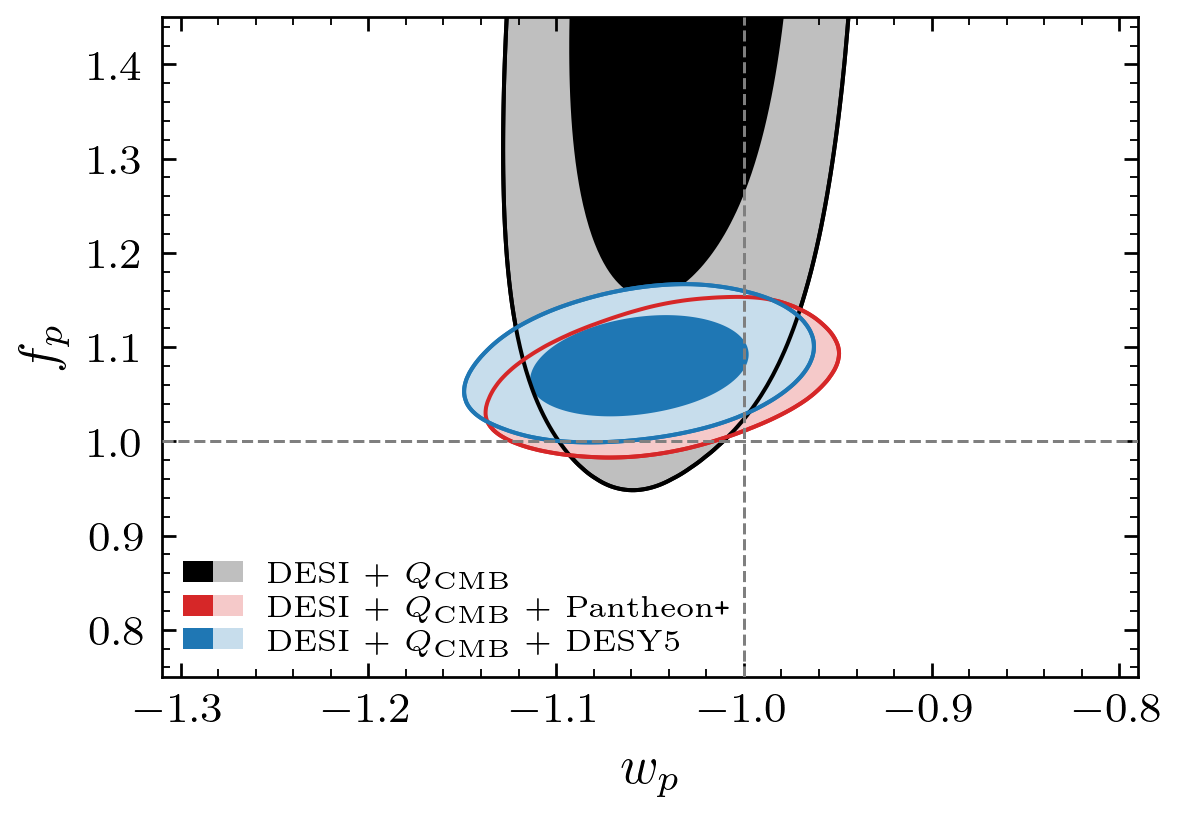

In [4]:
datas=[desi_cmb_fpwp_data,desi_cmb_pp_fpwp_data,desi_cmb_des_fpwp_data]
datas_str=['desi_cmb_fp_wp','desi_cmb_pp_fp_wp','desi_cmb_des_fp_wp']
datas_tex=[r'DESI + $Q_{\rm CMB}$',
           r'DESI + $Q_{\rm CMB}$ + Pantheon$\texttt{+}$',
           r'DESI + $Q_{\rm CMB}$ + DESY5']
css=[color_shades('k', 2),color_shades('tab:red', 2),color_shades('tab:blue', 2)]

fig = plt.figure(figsize=(3.5, 3.5/1.61803398875*1.1))
zorders=[2,3,4]
for i in range(len(datas)):
    X= datas[i][str(datas_str[i])+f"_wp_fld__fp_fld_x"]
    Y= datas[i][str(datas_str[i])+f"_wp_fld__fp_fld_y"]
    P= datas[i][str(datas_str[i])+f"_wp_fld__fp_fld_p_grid"]
    cls=datas[i][str(datas_str[i])+f"_wp_fld__fp_fld_contour_levels"]
    #cls=[cls[0],cls[2]]
    cls=cls[:2]
    lvs = sorted(np.append([P.max()+1], cls))
    #if i==0:    
    #    plt.contour(Y,X, P.T, levels=lvs, colors=[css[i][0],css[i][0]], linewidths=0.8,zorder=7,linestyles='--')
    #else:
    plt.contourf(Y,X, P.T, levels=lvs, colors=[css[i][1],css[i][0]],zorder=zorders[i])
    plt.contour(Y,X, P.T, levels=lvs, colors=[css[i][0],css[i][0]], linewidths=0.8,zorder=zorders[i])
    plt.contour(Y, X, P.T, levels=[cls[1], P.max() + 1], colors=[css[i][0]], linewidths=0.8, zorder=6)
plt.axhline(1,lw=.6,ls='--',c='tab:gray',zorder=8)
plt.axvline(-1,lw=.6,ls='--',c='tab:gray',zorder=8)
plt.xlim(-1.31,-0.79)
plt.xticks([-1.3,-1.2,-1.1,-1,-0.9,-0.8])
plt.xlabel(r"$w_p$")
plt.ylabel(r"$f_p$")
plt.ylim(0.75,1.45)
handles,labels=[],[]
for i in range(len(datas)):
    patch95 = Patch(facecolor=css[i][1])
    patch68 = Patch(facecolor=css[i][0])
    labels  += [datas_tex[i]]
    handles += [(patch68, patch95)]
leg = plt.legend(
    handles=handles,
    labels=labels,
    #loc=(1.0,0.8),
    loc=3,
    fontsize=6,
    handler_map={tuple: mpl.legend_handler.HandlerTuple(ndivide=None, pad=0.0)},
    )   
plt.savefig("figs/desi_cmb_sne_fpwp_v0.png")
plt.savefig("figs/desi_cmb_sne_fpwp_v0.pdf")
plt.show()

## Figure 2 (full): $(w_p, f_p)$ and $(w_0, w_a)$ side by side

Two-panel figure comparing the posteriors in the $(w_p, f_p)$ and $(w_0, w_a)$ planes.

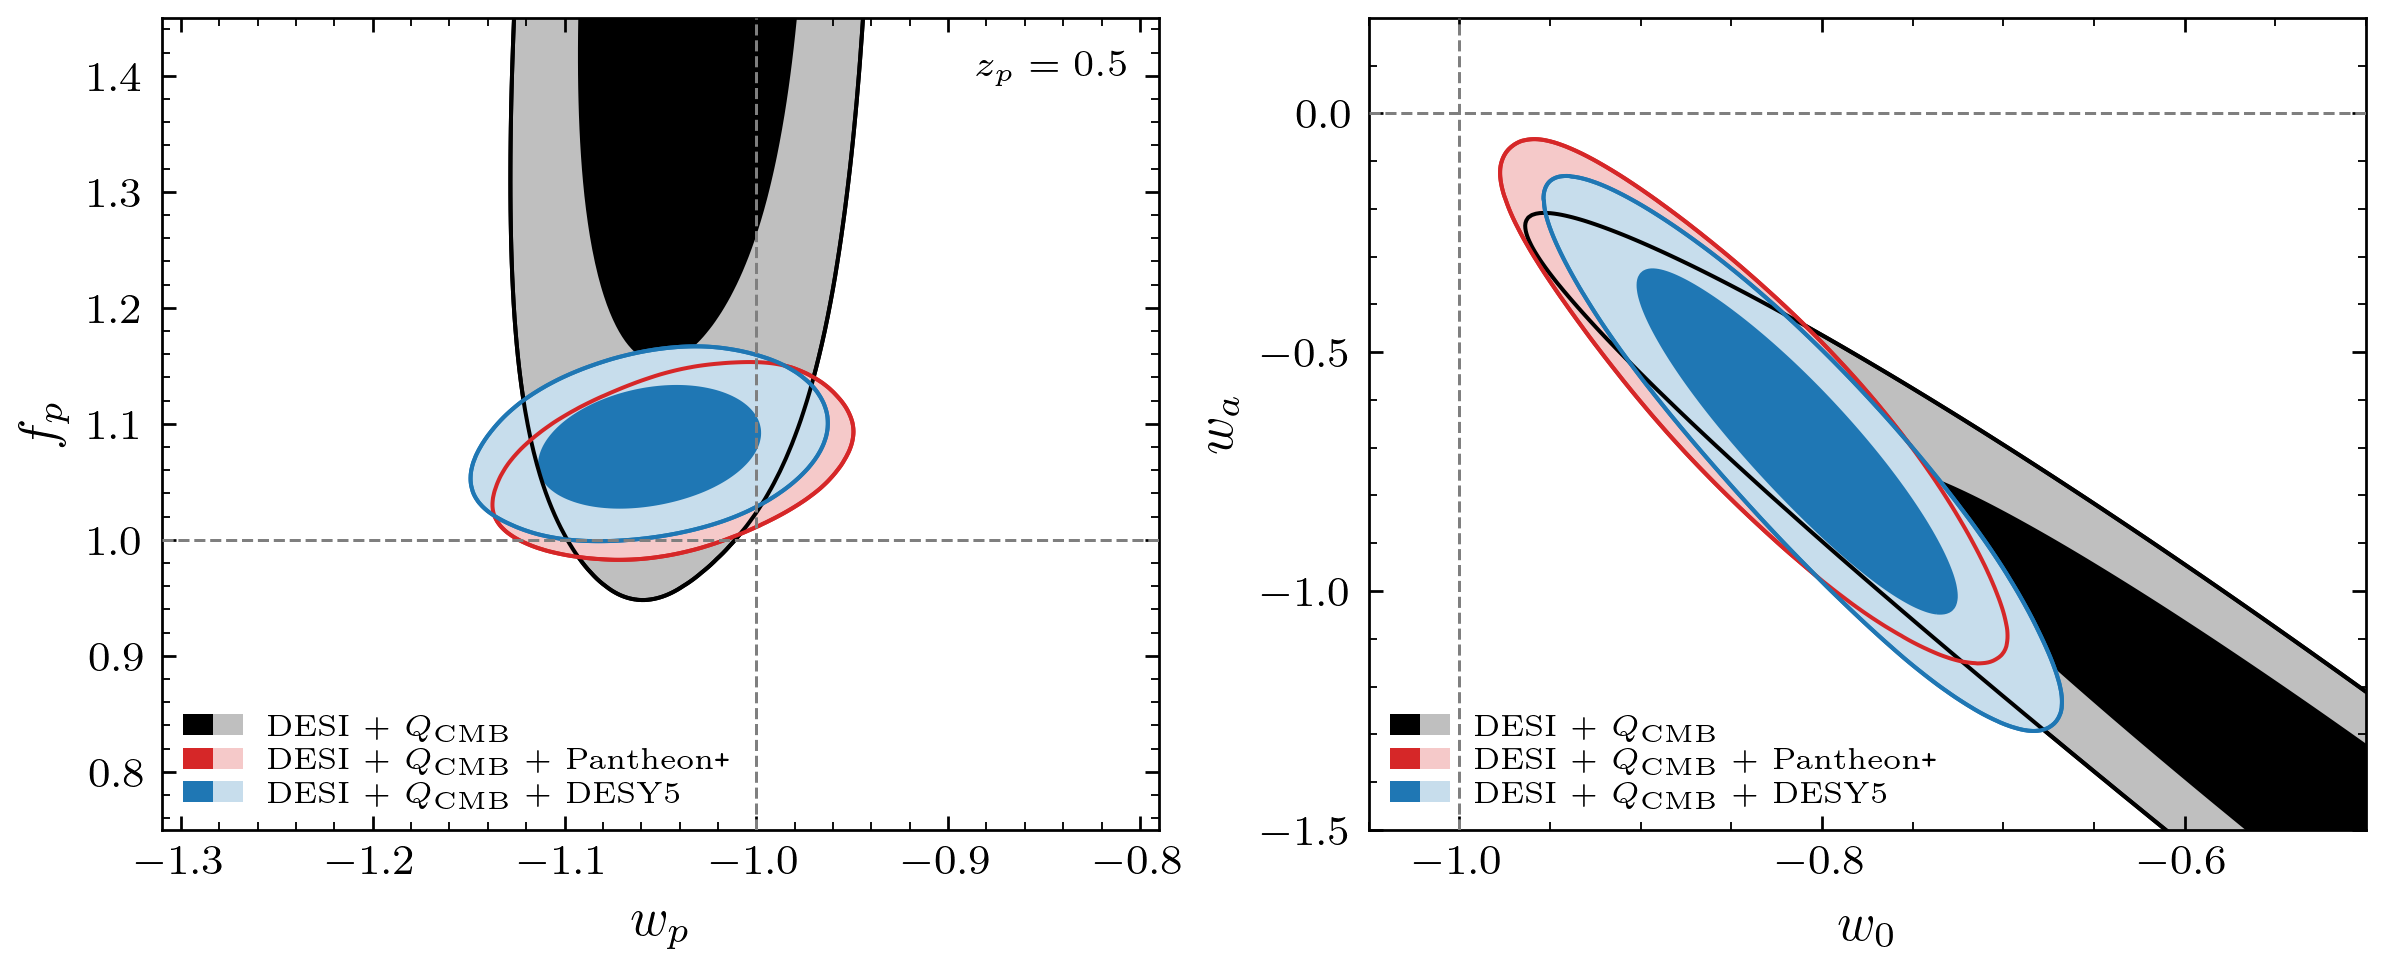

In [5]:
fig = plt.figure(figsize=(7.9, 7.9/1.61803398875*0.6))

gs = GridSpec(20, 44, figure=fig)  # 7 rows and 7 columns for the triangle plot
ax2= fig.add_subplot(gs[:, :20])
ax1= fig.add_subplot(gs[:, 24:])

datas=[desi_cmb_fpwp_data,desi_cmb_pp_fpwp_data,desi_cmb_des_fpwp_data]
datas_str=['desi_cmb_fp_wp','desi_cmb_pp_fp_wp','desi_cmb_des_fp_wp']
datas_tex=[r'DESI + $Q_{\rm CMB}$',
           r'DESI + $Q_{\rm CMB}$ + Pantheon$\texttt{+}$',
           r'DESI + $Q_{\rm CMB}$ + DESY5']
css=[color_shades('k', 2),color_shades('tab:red', 2),color_shades('tab:blue', 2)]
zorders=[2,3,4]
for i in range(len(datas)):
    X= datas[i][str(datas_str[i])+f"_wp_fld__fp_fld_x"]
    Y= datas[i][str(datas_str[i])+f"_wp_fld__fp_fld_y"]
    P= datas[i][str(datas_str[i])+f"_wp_fld__fp_fld_p_grid"]
    cls=datas[i][str(datas_str[i])+f"_wp_fld__fp_fld_contour_levels"]
    cls=cls[:2]
    lvs = sorted(np.append([P.max()+1], cls))
    ax2.contourf(Y,X, P.T, levels=lvs, colors=[css[i][1],css[i][0]],zorder=zorders[i])
    ax2.contour(Y,X, P.T, levels=lvs, colors=[css[i][0],css[i][0]], linewidths=0.8,zorder=zorders[i])
    ax2.contour(Y, X, P.T, levels=[cls[1], P.max() + 1], colors=[css[i][0]], linewidths=0.8, zorder=6)
ax2.axhline(1,lw=.6,ls='--',c='tab:gray',zorder=8)
ax2.axvline(-1,lw=.6,ls='--',c='tab:gray',zorder=8)
ax2.set_xlim(-1.31,-0.79)
ax2.set_xticks([-1.3,-1.2,-1.1,-1,-0.9,-0.8])
ax2.set_xlabel(r"$w_p$")
ax2.set_ylabel(r"$f_p$")
ax2.set_ylim(0.75,1.45)
handles,labels=[],[]
for i in range(len(datas)):
    patch95 = Patch(facecolor=css[i][1])
    patch68 = Patch(facecolor=css[i][0])
    labels  += [datas_tex[i]]
    handles += [(patch68, patch95)]
leg = ax2.legend(
    handles=handles,
    labels=labels,
    #loc=(1.0,0.8),
    loc=3,
    fontsize=6,
    handler_map={tuple: mpl.legend_handler.HandlerTuple(ndivide=None, pad=0.0)},
    )
css=[color_shades('k', 2),color_shades('tab:red', 2),color_shades('tab:blue', 2)]
datas=[desi_cmb_w0wa_data,desi_cmb_pp_w0wa_data,desi_cmb_des_w0wa_data]
datas_str=['desi_cmb_w0wa','desi_cmb_pp_w0wa','desi_cmb_des_w0wa']
for i in range(len(datas)):
    X= datas[i][str(datas_str[i])+f"_wa_fld__w0_fld_x"]
    Y= datas[i][str(datas_str[i])+f"_wa_fld__w0_fld_y"]
    P= datas[i][str(datas_str[i])+f"_wa_fld__w0_fld_p_grid"]
    cls=datas[i][str(datas_str[i])+f"_wa_fld__w0_fld_contour_levels"]
    #cls=[cls[0],cls[2]]
    cls=cls[:2]
    lvs = sorted(np.append([P.max()+1], cls))
    ax1.contourf(X,Y, P, levels=lvs, colors=[css[i][1],css[i][0]],zorder=zorders[i])
    ax1.contour(X,Y, P, levels=lvs, colors=[css[i][0],css[i][0]], linewidths=0.8,zorder=zorders[i])  
    ax1.contour(X, Y, P, levels=[cls[1], P.max() + 1], colors=[css[i][0]], linewidths=0.8, zorder=6)
ax1.axhline(0,lw=.6,ls='--',c='tab:gray',zorder=8)
ax1.axvline(-1,lw=.6,ls='--',c='tab:gray',zorder=8)
ax1.set_xlim(-1.05,-0.5)
ax1.set_ylim(-1.5,0.2)
ax1.set_xlabel(r"$w_0$")
ax1.set_ylabel(r"$w_a$")
ax1.set_xticks([-1,-0.8,-0.6])
ax1.set_yticks([-1.5,-1,-0.5,0])
leg = ax1.legend(
    handles=handles,
    labels=labels,
    #loc=(1.0,0.8),
    loc=3,
    fontsize=6,
    handler_map={tuple: mpl.legend_handler.HandlerTuple(ndivide=None, pad=0.0)},
    )
ax2.text(-0.805,1.4,r'$z_p=0.5$', fontsize=mpl.rcParams['legend.fontsize'], ha='right')
plt.savefig("figs/desi_cmb_sne_fpwp_w0wa_v0.png")
plt.savefig("figs/desi_cmb_sne_fpwp_w0wa_v0.pdf")
plt.show()
plt.close()

## Figure 3: Reconstructed $f_{\rm DE}(z)$ and $w(z)$

Compute the redshift evolution bands from the posterior samples, then plot the reconstructed DE density and equation of state.

In [6]:
desi_cmb_pp_fpwp_DEeV=get_wz_fDE_bands_fpwp(desi_cmb_pp_fpwp_data, "desi_cmb_pp_fp_wp",n_samples=10000,z_max=2.5)
desi_cmb_des_fpwp_DEeV=get_wz_fDE_bands_fpwp(desi_cmb_des_fpwp_data, "desi_cmb_des_fp_wp",n_samples=10000,z_max=5)
desi_cmb_fpwp_DEeV=get_wz_fDE_bands_fpwp(desi_cmb_fpwp_data, "desi_cmb_fp_wp",n_samples=10000,z_max=2.5)
desi_cmb_pp_w0wa_DEeV=get_wz_fDE_bands_w0wa(desi_cmb_pp_w0wa_data, "desi_cmb_pp_w0wa",n_samples=10000,z_max=2.5)
desi_cmb_des_w0wa_DEeV=get_wz_fDE_bands_w0wa(desi_cmb_des_w0wa_data, "desi_cmb_des_w0wa",n_samples=10000,z_max=2.5)
desi_cmb_w0wa_DEeV=get_wz_fDE_bands_w0wa(desi_cmb_w0wa_data, "desi_cmb_w0wa",n_samples=10000,z_max=2.5)

In [7]:
class HandlerFillLine(HandlerBase):
    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                       width, height, fontsize, trans):
        color_2s, alpha_2s, color_1s, alpha_1s, linecolor, lw = orig_handle

        # 2-sigma rectangle (full height)
        patch_2s = Rectangle((xdescent, ydescent), width, height,
                             facecolor=color_2s, alpha=alpha_2s,
                             edgecolor='none', transform=trans)

        # 1-sigma rectangle (narrower band around center)
        inner_h = height * 0.55
        patch_1s = Rectangle((xdescent, ydescent + (height - inner_h) / 2),
                             width, inner_h,
                             facecolor=color_1s, alpha=alpha_1s,
                             edgecolor='none', transform=trans)

        # Mean line across the center
        line = plt.Line2D([xdescent, xdescent + width],
                          [ydescent + height / 2, ydescent + height / 2],
                          color=linecolor, lw=lw, transform=trans)

        return [patch_2s, patch_1s, line]

### DESI + $Q_{\rm CMB}$ + DESY5

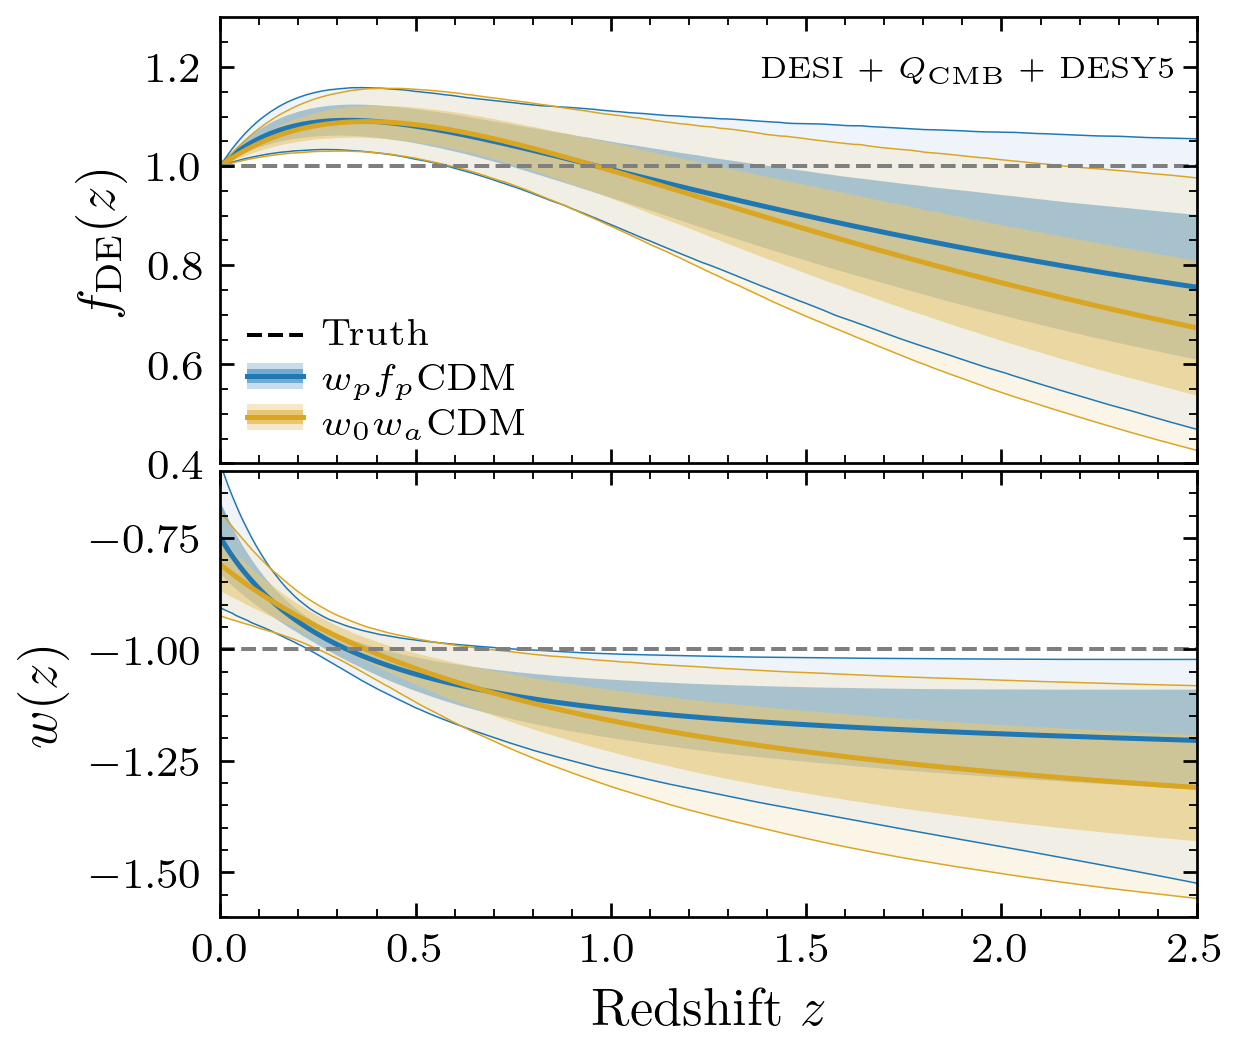

In [13]:
fig = plt.figure(figsize=(3.5, 3.5/1.61803398875*1.5))
cs=color_shades('goldenrod', 3)
cs2=color_shades('tab:blue', 3)
gs = GridSpec(20, 20, figure=fig)  # 7 rows and 7 columns for the triangle plot
ax2= fig.add_subplot(gs[:10, :])
ax1= fig.add_subplot(gs[10:, :])

# Plot wider band (fpwp, blue) first with lower alpha
ax1.fill_between(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['w_lo2'],desi_cmb_des_fpwp_DEeV['w_hi2'],color=cs2[2],alpha=.3,lw=0,zorder=.2)
ax1.fill_between(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['w_lo1'],desi_cmb_des_fpwp_DEeV['w_hi1'],color=cs2[1],alpha=1,lw=0,zorder=.3)
ax1.plot(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['w_mean'],c=cs2[0],lw=1,zorder=.6)
ax1.plot(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['w_lo2'],c=cs2[0],lw=.3,zorder=.6)
ax1.plot(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['w_hi2'],c=cs2[0],lw=.3,zorder=.6)

ax2.fill_between(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['fDE_lo2'],desi_cmb_des_fpwp_DEeV['fDE_hi2'],color=cs2[2],alpha=.3,lw=0,zorder=.2)
ax2.fill_between(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['fDE_lo1'],desi_cmb_des_fpwp_DEeV['fDE_hi1'],color=cs2[1],alpha=1,lw=0,zorder=.3)
ax2.plot(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['fDE_mean'],c=cs2[0],lw=1,zorder=.6)
ax2.plot(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['fDE_lo2'],c=cs2[0],lw=.3,zorder=.6)
ax2.plot(desi_cmb_des_fpwp_DEeV['z'],desi_cmb_des_fpwp_DEeV['fDE_hi2'],c=cs2[0],lw=.3,zorder=.6)

# Plot narrower band (w0wa, goldenrod) on top with higher alpha
ax1.fill_between(desi_cmb_des_w0wa_DEeV['z'],desi_cmb_des_w0wa_DEeV['w_lo2'],desi_cmb_des_w0wa_DEeV['w_hi2'],color=cs[2],alpha=.4,lw=0,zorder=.4)
ax1.fill_between(desi_cmb_des_w0wa_DEeV['z'],desi_cmb_des_w0wa_DEeV['w_lo1'],desi_cmb_des_w0wa_DEeV['w_hi1'],color=cs[1],alpha=.6,lw=0,zorder=.5)
ax1.plot(desi_cmb_des_w0wa_DEeV['z'],desi_cmb_des_w0wa_DEeV['w_mean'],c=cs[0],lw=1,zorder=.7)
ax1.plot(desi_cmb_des_w0wa_DEeV['z'],desi_cmb_des_w0wa_DEeV['w_lo2'],c=cs[0],lw=.3,zorder=.7)
ax1.plot(desi_cmb_des_w0wa_DEeV['z'],desi_cmb_des_w0wa_DEeV['w_hi2'],c=cs[0],lw=.3,zorder=.7)

ax2.fill_between(desi_cmb_des_w0wa_DEeV['z'],desi_cmb_des_w0wa_DEeV['fDE_lo2'],desi_cmb_des_w0wa_DEeV['fDE_hi2'],color=cs[2],alpha=.4,lw=0,zorder=.4)
ax2.fill_between(desi_cmb_des_w0wa_DEeV['z'],desi_cmb_des_w0wa_DEeV['fDE_lo1'],desi_cmb_des_w0wa_DEeV['fDE_hi1'],color=cs[1],alpha=.6,lw=0,zorder=.5)
ax2.plot(desi_cmb_des_w0wa_DEeV['z'],desi_cmb_des_w0wa_DEeV['fDE_mean'],c=cs[0],lw=1,zorder=.7)
ax2.plot(desi_cmb_des_w0wa_DEeV['z'],desi_cmb_des_w0wa_DEeV['fDE_lo2'],c=cs[0],lw=.3,zorder=.7)
ax2.plot(desi_cmb_des_w0wa_DEeV['z'],desi_cmb_des_w0wa_DEeV['fDE_hi2'],c=cs[0],lw=.3,zorder=.7)

ax2.text(2.45,1.18,r'DESI + $Q_{\rm CMB}$ + DESY5', fontsize=0.8*mpl.rcParams['legend.fontsize'], ha='right')
ax1.axhline(-1,c='tab:gray',ls='--',lw=0.8,zorder=.8)
ax2.axhline(1,c='tab:gray',ls='--',lw=0.8,zorder=.8)
handles = [
    (cs2[2], 1,cs2[1], 1, cs2[0], 1),
    (cs[2], 1, cs[1], 1, cs[0], 1)
]
labels = [r'',
          r'']
ax2.text(0.26,.57,r'$w_pf_p$CDM', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
ax2.text(0.26,.48,r'$w_0w_a$CDM', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
# Create legend
legend1 =ax2.legend(handles, labels,
          handler_map={tuple: HandlerFillLine()},
          handlelength=1.5,handletextpad=0.5,
                   loc=3)
ax2.add_artist(legend1)
ax1.set_xlim(0,2.5)
ax2.set_xlim(0,2.5)
ax1.set_xticks([0,0.5,1,1.5,2.,2.5])
ax2.set_xticks([0,0.5,1,1.5,2.,2.5])
ax2.set_xticklabels([])
ax1.set_xlabel(r"Redshift $z$")
ax1.set_ylabel(r"$w(z)$")
ax2.set_ylabel(r"$f_{\rm DE}(z)$")
ax1.set_ylim(-1.6,-0.6)
ax1.set_yticks([-1.5,-1.25,-1,-0.75])
ax2.set_ylim(0.4,1.3)
plt.savefig("figs/desi_cmb_sne_fDE_wzEv_v0.png")
plt.savefig("figs/desi_cmb_sne_fDE_wzEv_v0.pdf")
plt.show()
plt.close()

### DESI + $Q_{\rm CMB}$ + Pantheon+

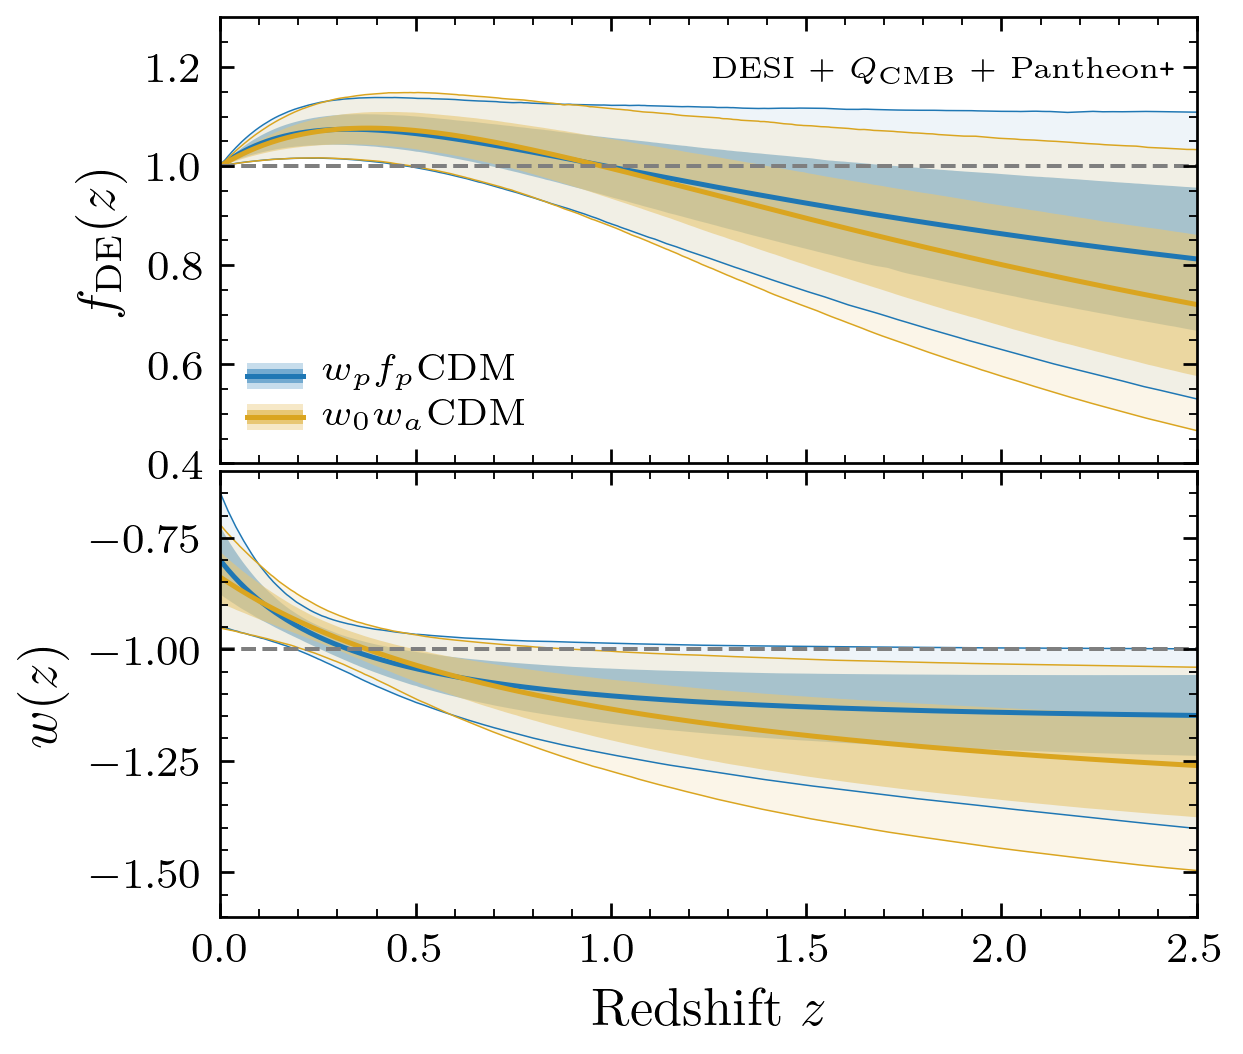

In [8]:
fig = plt.figure(figsize=(3.5, 3.5/1.61803398875*1.5))
cs=color_shades('goldenrod', 3)
cs2=color_shades('tab:blue', 3)
gs = GridSpec(20, 20, figure=fig)  # 7 rows and 7 columns for the triangle plot
ax2= fig.add_subplot(gs[:10, :])
ax1= fig.add_subplot(gs[10:, :])

# Plot wider band (fpwp, blue) first with lower alpha
ax1.fill_between(desi_cmb_pp_fpwp_DEeV['z'],desi_cmb_pp_fpwp_DEeV['w_lo2'],desi_cmb_pp_fpwp_DEeV['w_hi2'],color=cs2[2],alpha=.3,lw=0,zorder=.2)
ax1.fill_between(desi_cmb_pp_fpwp_DEeV['z'],desi_cmb_pp_fpwp_DEeV['w_lo1'],desi_cmb_pp_fpwp_DEeV['w_hi1'],color=cs2[1],alpha=1,lw=0,zorder=.3)
ax1.plot(desi_cmb_pp_fpwp_DEeV['z'],desi_cmb_pp_fpwp_DEeV['w_mean'],c=cs2[0],lw=1,zorder=.6)
ax1.plot(desi_cmb_pp_fpwp_DEeV['z'],desi_cmb_pp_fpwp_DEeV['w_lo2'],c=cs2[0],lw=.3,zorder=.6)
ax1.plot(desi_cmb_pp_fpwp_DEeV['z'],desi_cmb_pp_fpwp_DEeV['w_hi2'],c=cs2[0],lw=.3,zorder=.6)

ax2.fill_between(desi_cmb_pp_fpwp_DEeV['z'],desi_cmb_pp_fpwp_DEeV['fDE_lo2'],desi_cmb_pp_fpwp_DEeV['fDE_hi2'],color=cs2[2],alpha=.3,lw=0,zorder=.2)
ax2.fill_between(desi_cmb_pp_fpwp_DEeV['z'],desi_cmb_pp_fpwp_DEeV['fDE_lo1'],desi_cmb_pp_fpwp_DEeV['fDE_hi1'],color=cs2[1],alpha=1,lw=0,zorder=.3)
ax2.plot(desi_cmb_pp_fpwp_DEeV['z'],desi_cmb_pp_fpwp_DEeV['fDE_mean'],c=cs2[0],lw=1,zorder=.6)
ax2.plot(desi_cmb_pp_fpwp_DEeV['z'],desi_cmb_pp_fpwp_DEeV['fDE_lo2'],c=cs2[0],lw=.3,zorder=.6)
ax2.plot(desi_cmb_pp_fpwp_DEeV['z'],desi_cmb_pp_fpwp_DEeV['fDE_hi2'],c=cs2[0],lw=.3,zorder=.6)

# Plot narrower band (w0wa, goldenrod) on top with higher alpha
ax1.fill_between(desi_cmb_pp_w0wa_DEeV['z'],desi_cmb_pp_w0wa_DEeV['w_lo2'],desi_cmb_pp_w0wa_DEeV['w_hi2'],color=cs[2],alpha=.4,lw=0,zorder=.4)
ax1.fill_between(desi_cmb_pp_w0wa_DEeV['z'],desi_cmb_pp_w0wa_DEeV['w_lo1'],desi_cmb_pp_w0wa_DEeV['w_hi1'],color=cs[1],alpha=.6,lw=0,zorder=.5)
ax1.plot(desi_cmb_pp_w0wa_DEeV['z'],desi_cmb_pp_w0wa_DEeV['w_mean'],c=cs[0],lw=1,zorder=.7)
ax1.plot(desi_cmb_pp_w0wa_DEeV['z'],desi_cmb_pp_w0wa_DEeV['w_lo2'],c=cs[0],lw=.3,zorder=.7)
ax1.plot(desi_cmb_pp_w0wa_DEeV['z'],desi_cmb_pp_w0wa_DEeV['w_hi2'],c=cs[0],lw=.3,zorder=.7)

ax2.fill_between(desi_cmb_pp_w0wa_DEeV['z'],desi_cmb_pp_w0wa_DEeV['fDE_lo2'],desi_cmb_pp_w0wa_DEeV['fDE_hi2'],color=cs[2],alpha=.4,lw=0,zorder=.4)
ax2.fill_between(desi_cmb_pp_w0wa_DEeV['z'],desi_cmb_pp_w0wa_DEeV['fDE_lo1'],desi_cmb_pp_w0wa_DEeV['fDE_hi1'],color=cs[1],alpha=.6,lw=0,zorder=.5)
ax2.plot(desi_cmb_pp_w0wa_DEeV['z'],desi_cmb_pp_w0wa_DEeV['fDE_mean'],c=cs[0],lw=1,zorder=.7)
ax2.plot(desi_cmb_pp_w0wa_DEeV['z'],desi_cmb_pp_w0wa_DEeV['fDE_lo2'],c=cs[0],lw=.3,zorder=.7)
ax2.plot(desi_cmb_pp_w0wa_DEeV['z'],desi_cmb_pp_w0wa_DEeV['fDE_hi2'],c=cs[0],lw=.3,zorder=.7)

ax2.text(2.45,1.18,r'DESI + $Q_{\rm CMB}$ + Pantheon$\texttt{+}$', fontsize=0.8*mpl.rcParams['legend.fontsize'], ha='right')
ax1.axhline(-1,c='tab:gray',ls='--',lw=0.8,zorder=.8)
ax2.axhline(1,c='tab:gray',ls='--',lw=0.8,zorder=.8)
handles = [
    (cs2[2], 1,cs2[1], 1, cs2[0], 1),
    (cs[2], 1, cs[1], 1, cs[0], 1)
]
labels = [r'',
          r'']
ax2.text(0.26,.57,r'$w_pf_p$CDM', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
ax2.text(0.26,.48,r'$w_0w_a$CDM', fontsize=mpl.rcParams['legend.fontsize'], ha='left')
# Create legend
legend1 =ax2.legend(handles, labels,
          handler_map={tuple: HandlerFillLine()},
          handlelength=1.5,handletextpad=0.5)
ax2.add_artist(legend1)
ax1.set_xlim(0,2.5)
ax2.set_xlim(0,2.5)
ax1.set_xticks([0,0.5,1,1.5,2.,2.5])
ax2.set_xticks([0,0.5,1,1.5,2.,2.5])
ax2.set_xticklabels([])
ax1.set_xlabel(r"Redshift $z$")
ax1.set_ylabel(r"$w(z)$")
ax2.set_ylabel(r"$f_{\rm DE}(z)$")
ax1.set_ylim(-1.6,-0.6)
ax1.set_yticks([-1.5,-1.25,-1,-0.75])
ax2.set_ylim(0.4,1.3)
plt.savefig("figs/desi_cmb_pp_fDE_wzEv_v0.png")
plt.savefig("figs/desi_cmb_pp_fDE_wzEv_v0.pdf")
plt.show()
plt.close()

## Table 1: Parameter constraints

Print the marginalized 68% C.L. bounds for all models and dataset combinations.

In [ ]:
def print_bounds(pars, datas, datas_str, label):
    """Print mean and 68% C.L. bounds for a list of parameters and datasets."""
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    for i in range(len(datas)):
        print(f"\n--- {datas_str[i]} ---")
        for par in pars:
            mean = datas[i][f"{datas_str[i]}_{par}_1D_mean"]
            lims = datas[i][f"{datas_str[i]}_{par}_1D_68limits"]
            lo, hi = mean - lims[0], mean - lims[1]
            print(f"  {par:12s}: {mean:.4f}  (+{abs(hi):.4f} / -{abs(lo):.4f})")

In [ ]:
print_bounds(
    pars=['Omega_m', 'H0'],
    datas=[desi_cmb_lcdm_data, desi_cmb_pp_lcdm_data, desi_cmb_des_lcdm_data],
    datas_str=['desi_cmb_lcdm', 'desi_cmb_pp_lcdm', 'desi_cmb_des_lcdm'],
    label="LCDM constraints (Table 1, top)"
)

In [ ]:
print_bounds(
    pars=['Omega_m', 'H0', 'fp_fld', 'wp_fld'],
    datas=[desi_cmb_fpwp_data, desi_cmb_pp_fpwp_data, desi_cmb_des_fpwp_data],
    datas_str=['desi_cmb_fp_wp', 'desi_cmb_pp_fp_wp', 'desi_cmb_des_fp_wp'],
    label="wp fp CDM constraints (Table 1, bottom)"
)

In [ ]:
print_bounds(
    pars=['Omega_m', 'H0', 'w0_fld', 'wa_fld'],
    datas=[desi_cmb_w0wa_data, desi_cmb_pp_w0wa_data, desi_cmb_des_w0wa_data],
    datas_str=['desi_cmb_w0wa', 'desi_cmb_pp_w0wa', 'desi_cmb_des_w0wa'],
    label="w0 wa CDM constraints (Table 1, middle)"
)